In [1]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
import spectral as spy

In [2]:
path = '../result/SA_label_test_predict.csv'
data = pd.read_csv(path)
data = data[['predict label']]
data = data.values
print(type(data))

<class 'numpy.ndarray'>


D:\Software\DevelopEnvironment\Miniconda\envs\dlpth112\lib\site-packages\spectral\graphics\spypylab.py:796: UserWarning: Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.
  warnings.warn(msg)


<class 'numpy.ndarray'>
(512, 217)
uint8


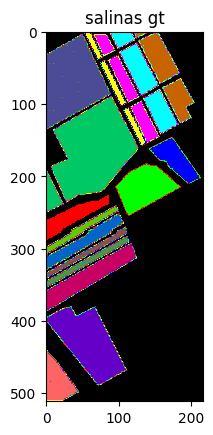

In [3]:
gt = loadmat('../dataset/7_Salinas/Salinas_gt.mat')['salinas_gt']
view1 = spy.imshow(classes=gt, title="salinas gt")  # 地物类别显示
print(type(gt))
print(gt.shape)
print(gt.dtype)

In [4]:
# np.set_printoptions(threshold=np.inf)
print(gt)
print(gt.max())

[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [16 16 16 ...  0  0  0]
 [16 16 16 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]
16


In [5]:
# # 将预测的结果匹配到图像中
new_show = np.zeros((gt.shape[0], gt.shape[1]))
k = 0
for i in range(gt.shape[0]):
    for j in range(gt.shape[1]):
        if gt[i][j] != 0:
            new_show[i][j] = data[k]
            new_show[i][j] += 1
            k += 1

print(new_show.shape)
print(type(new_show))
print(new_show.dtype)
new_show = (new_show).round().astype(np.uint8)
print(new_show.dtype)

(512, 217)
<class 'numpy.ndarray'>
float64
uint8


In [6]:
print(new_show)
print(new_show.max())

[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [16 16 16 ...  0  0  0]
 [16 16 16 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]
16


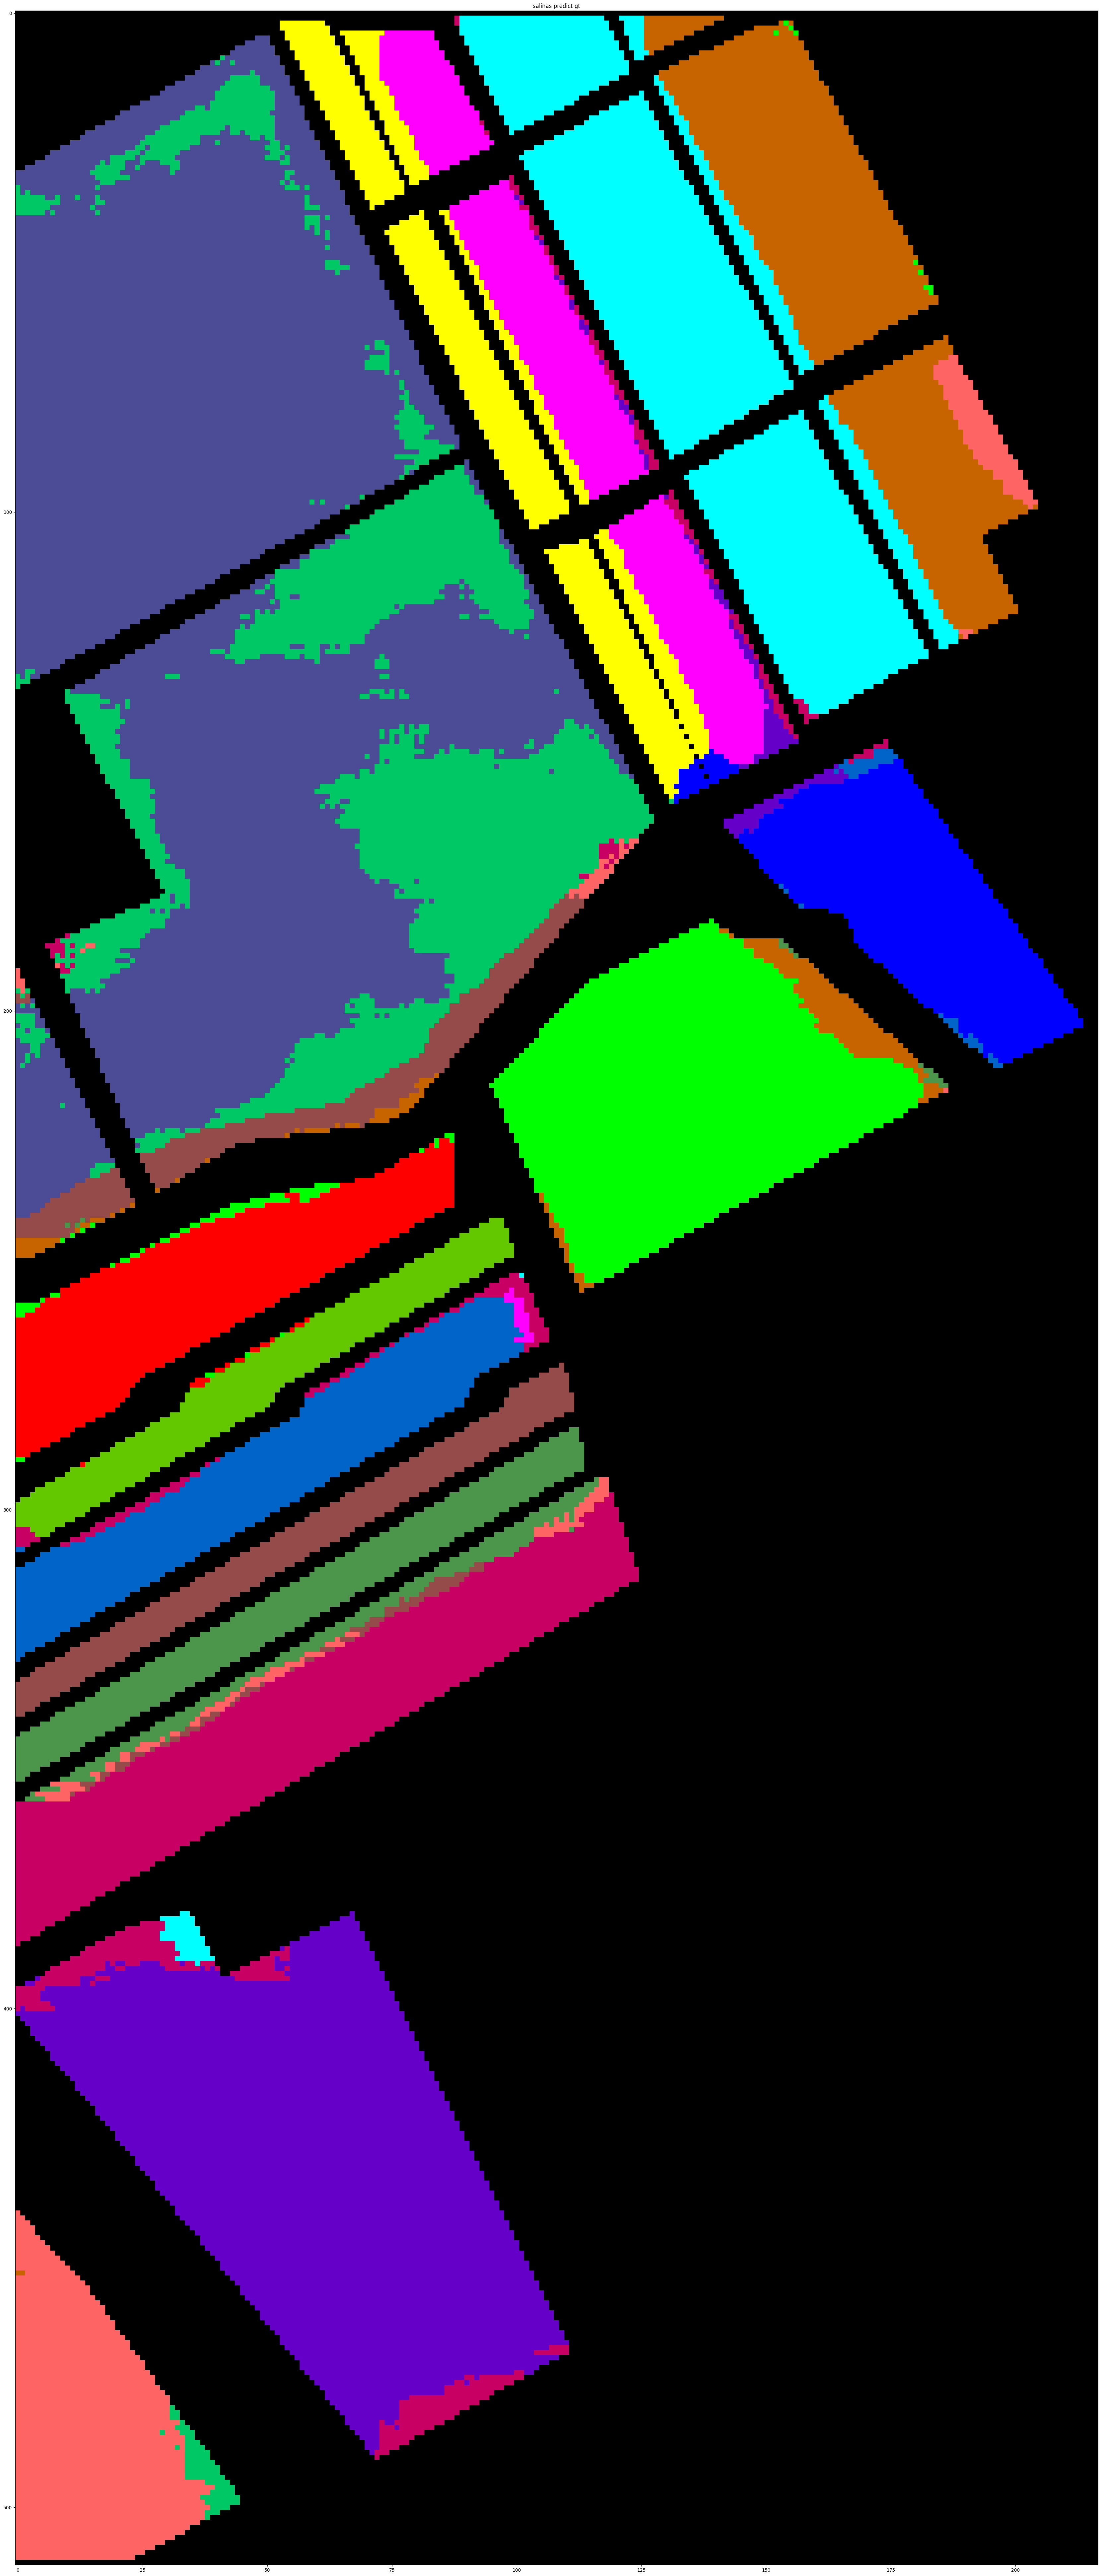

In [7]:
view2 = spy.imshow(classes=new_show, title="salinas predict gt", figsize=(100, 100))  # 地物类别显示

In [8]:
print(gt == new_show)

[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


In [9]:
# np.set_printoptions(threshold=np.inf)
# print(gt == new_show)

In [10]:
true_count = 0
false_count = 0

for i in range(gt.shape[0]):
    for j in range(gt.shape[1]):
        if gt[i][j] == new_show[i][j]:
            true_count +=1
        else:
            false_count +=1  
            
print(true_count, false_count)

100166 10938


In [11]:
true_count / (true_count + false_count)

0.9015516993087558